In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Fifa_world_cup_2022_matches.csv')
df.head(65)

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20-Nov-22,17:00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21-Nov-22,14:00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21-Nov-22,17:00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21-Nov-22,20:00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22-Nov-22,11:00,Group C,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,ENGLAND,FRANCE,54%,36%,10%,1,2,10-Dec-22,20:00,Quarter-final,...,1,0,9,15,0,0,49,54,193,308
60,ARGENTINA,CROATIA,34%,54%,12%,3,0,13-Dec-22,20:00,Semi-final,...,1,0,12,10,0,0,85,63,321,260
61,FRANCE,MOROCCO,34%,55%,11%,2,0,14-Dec-22,20:00,Semi-final,...,0,0,13,14,0,0,72,47,328,218
62,CROATIA,MOROCCO,45%,45%,10%,2,1,17-Dec-22,16:00,Play-off for third place,...,0,0,7,14,0,0,75,72,288,277


- Seleções participantes da Copa 2022:

Total de times: 32
['QATAR' 'ECUADOR' 'ENGLAND' 'IRAN' 'SENEGAL' 'NETHERLANDS'
 'UNITED STATES' 'WALES' 'ARGENTINA' 'SAUDI ARABIA' 'DENMARK' 'TUNISIA'
 'MEXICO' 'POLAND' 'FRANCE' 'AUSTRALIA' 'MOROCCO' 'CROATIA' 'GERMANY'
 'JAPAN' 'SPAIN' 'COSTA RICA' 'BELGIUM' 'CANADA' 'SWITZERLAND' 'CAMEROON'
 'URUGUAY' 'KOREA REPUBLIC' 'PORTUGAL' 'GHANA' 'BRAZIL' 'SERBIA']
----------------------------------------------------------------------------------------------------

Total de jogos: 64

Seleção com mais gols: FRANCE (16 gols)

Seleção mais vazada: COSTA RICA (11 gols sofridos)

Melhor saldo: ENGLAND
Pior saldo: COSTA RICA

Jogo com mais gols: ENGLAND x IRAN (8 gols)

----------------------------------------------------------------------------------------------------

Ranking de aproveitamento:

                vitorias  empates  jogos  pontos  aproveitamento
FRANCE               5.0      1.0      7    16.0       76.190476
NETHERLANDS          3.0      2.0

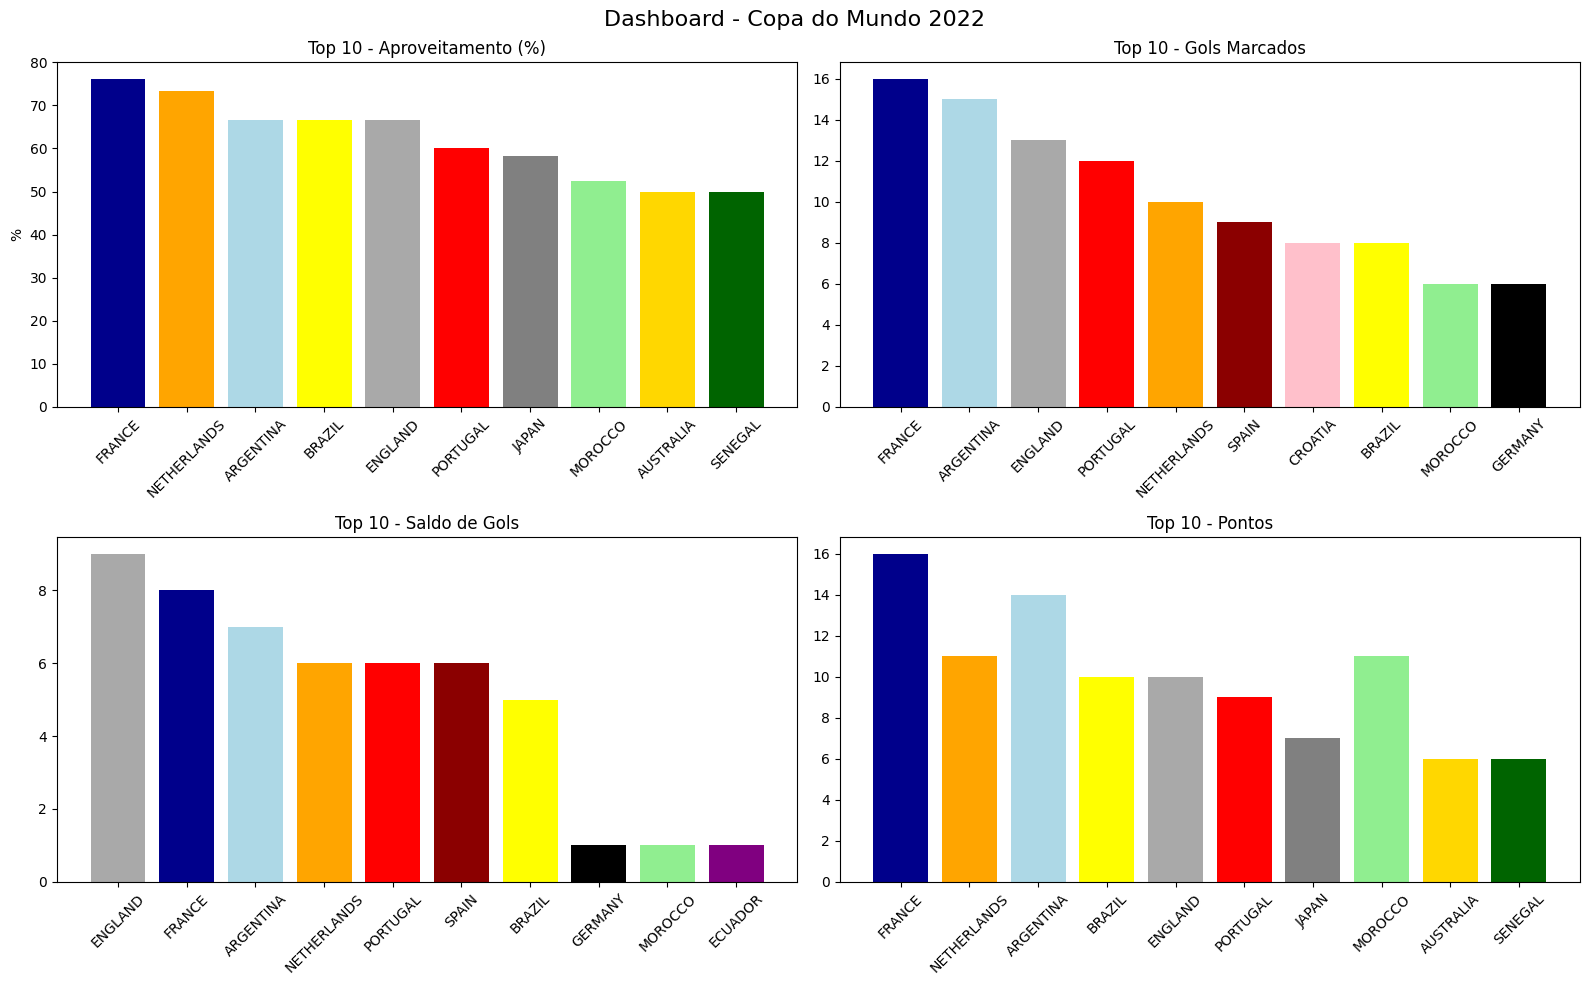

In [11]:
# ================================
# TIMES E JOGOS
# ================================

print('- Seleções participantes da Copa 2022:\n')

times = pd.unique(df[['team1','team2']].values.ravel())
print("Total de times:", len(times))
print(times)
print('-' * 100)

quantidade_jogos = len(df)
print(f'\nTotal de jogos: {quantidade_jogos}\n')

# ================================
# GOLS MARCADOS
# ================================

df_team1 = df[['team1', 'number of goals team1']].rename(columns={'team1':'team', 'number of goals team1':'goals'})
df_team2 = df[['team2', 'number of goals team2']].rename(columns={'team2':'team', 'number of goals team2':'goals'})

gols_por_time = pd.concat([df_team1, df_team2]).groupby('team').sum()

time_mais_gols = gols_por_time['goals'].idxmax()
qtd_gols = gols_por_time.loc[time_mais_gols, 'goals']

print(f'Seleção com mais gols: {time_mais_gols} ({qtd_gols} gols)\n')

# ================================
# GOLS SOFRIDOS
# ================================

df_gols_sofridos_1 = df[['team1', 'number of goals team2']].rename(columns={'team1':'team', 'number of goals team2':'goals_conceded'})
df_gols_sofridos_2 = df[['team2', 'number of goals team1']].rename(columns={'team2':'team', 'number of goals team1':'goals_conceded'})

gols_sofridos = pd.concat([df_gols_sofridos_1, df_gols_sofridos_2]).groupby('team').sum()

time_mais_vazado = gols_sofridos['goals_conceded'].idxmax()
qtd_sofridos = gols_sofridos.loc[time_mais_vazado, 'goals_conceded']

print(f'Seleção mais vazada: {time_mais_vazado} ({qtd_sofridos} gols sofridos)\n')

# ================================
# SALDO DE GOLS
# ================================

tabela_geral = pd.concat([gols_por_time, gols_sofridos], axis=1)
tabela_geral['saldo'] = tabela_geral['goals'] - tabela_geral['goals_conceded']

print(f'Melhor saldo: {tabela_geral["saldo"].idxmax()}')
print(f'Pior saldo: {tabela_geral["saldo"].idxmin()}\n')

# ================================
# JOGO COM MAIS GOLS
# ================================

df['total_goals'] = df['number of goals team1'] + df['number of goals team2']

jogo = df.loc[df['total_goals'].idxmax()]
print(f'Jogo com mais gols: {jogo["team1"]} x {jogo["team2"]} ({jogo["total_goals"]} gols)\n')
print('-' * 100)
print()

# ================================
# RESULTADO DOS JOGOS
# ================================

df['winner'] = np.where(
    df['number of goals team1'] > df['number of goals team2'],
    df['team1'],
    np.where(
        df['number of goals team2'] > df['number of goals team1'],
        df['team2'],
        'DRAW'
    )
)

# ================================
# VITÓRIAS
# ================================

vitorias_por_time = df[df['winner'] != 'DRAW']['winner'].value_counts().to_frame(name='vitorias')

# ================================
# EMPATES
# ================================

df['empate_flag'] = df['number of goals team1'] == df['number of goals team2']

df_empates = df[df['empate_flag']]

empates_por_time = pd.concat([
    df_empates['team1'],
    df_empates['team2']
]).value_counts().to_frame(name='empates')

# ================================
# JOGOS POR TIME
# ================================

jogos_por_time = pd.concat([df_team1['team'], df_team2['team']]).value_counts().to_frame(name='jogos')

# ================================
# TABELA FINAL
# ================================

tabela_final = pd.concat([
    vitorias_por_time,
    empates_por_time,
    jogos_por_time
], axis=1).fillna(0)

# ================================
# PONTOS + APROVEITAMENTO
# ================================

tabela_final['pontos'] = (tabela_final['vitorias'] * 3) + tabela_final['empates']

tabela_final['aproveitamento'] = (
    tabela_final['pontos'] / (tabela_final['jogos'] * 3)
) * 100

# ================================
# RANKING
# ================================

tabela_final = tabela_final.sort_values(by='aproveitamento', ascending=False)

print('Ranking de aproveitamento:\n')
print(tabela_final[['vitorias', 'empates', 'jogos', 'pontos', 'aproveitamento']])
print()

# ================================
# GRÁFICOS
# ================================

plt.figure(figsize=(16, 10))

# ================================
# TOP 10 APROVEITAMENTO
# ================================

cores_times = {
    'FRANCE': 'darkblue',
    'ARGENTINA': 'lightblue',
    'NETHERLANDS': 'orange',
    'BRAZIL': 'yellow',
    'ENGLAND': 'darkgray',
    'PORTUGAL': 'red',
    'JAPAN': 'gray',
    'MOROCCO': 'lightgreen',
    'AUSTRALIA': 'gold',
    'SENEGAL': 'darkgreen',
    'SPAIN' : 'darkred',
    'CROATIA' : 'pink',
    'GERMANY' : 'black',
    'ECUADOR' : 'purple'
}

top10 = tabela_final.head(10)
cores_aproveitamento = [cores_times.get(time, 'blue') for time in top10.index]

plt.subplot(2, 2, 1)
plt.bar(top10.index, top10['aproveitamento'], color=cores_aproveitamento)
plt.xticks(rotation=45)
plt.title('Top 10 - Aproveitamento (%)')
plt.ylabel('%')

# ================================
# TOP 10 GOLS MARCADOS
# ================================

top_gols = gols_por_time.sort_values(by='goals', ascending=False).head(10)
cores_gols = [cores_times.get(time, 'blue') for time in top_gols.index]

plt.subplot(2, 2, 2)
plt.bar(top_gols.index, top_gols['goals'], color=cores_gols)
plt.xticks(rotation=45)
plt.title('Top 10 - Gols Marcados')

# ================================
# TOP 10 SALDO DE GOLS
# ================================

top_saldo = tabela_geral.sort_values(by='saldo', ascending=False).head(10)
cores_saldo = [cores_times.get(time, 'blue') for time in top_saldo.index]

plt.subplot(2, 2, 3)
plt.bar(top_saldo.index, top_saldo['saldo'], color=cores_saldo)
plt.xticks(rotation=45)
plt.title('Top 10 - Saldo de Gols')

# ================================
# TOP 10 PONTOS
# ================================

top_pontos = tabela_final.head(10)
cores_pontos = [cores_times.get(time, 'blue') for time in top_pontos.index]

plt.subplot(2, 2, 4)
plt.bar(top_pontos.index, top_pontos['pontos'], color=cores_pontos)
plt.xticks(rotation=45)
plt.title('Top 10 - Pontos')

# ================================
# AJUSTE FINAL
# ================================

plt.suptitle('Dashboard - Copa do Mundo 2022', fontsize=16)
plt.tight_layout()
plt.show()